In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplot
from scipy.integrate import odeint
from scipy.optimize import least_squares, minimize
from ITIS_Model_funcs import get_nominal_param, ITIS, OLS_res
import pickle

In [20]:
paramtitles = ['d1',
'k1','k2','h1','h2','h3','d2',
'k3','k4','h4','d3',
'h5','h6','k5','k6','h7','d4',
'b1','k7','h8','k8','h9','d5','h10',
'b2','k9','k10','k11','d6',
'k12','k13','k14','h11','d7',
'k15','k16','d8',
'alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc']

stateTitles = ['Endotoxin', 'Phagocytes', 'TGF-\u03b2','TNF-\u03B1','IL10','CRH','ACTH','Cortisol']

In [21]:
param_log,IC = get_nominal_param()

##Define time spaces
tstart = 0
t_end =24*8
dt = .05
tspace = np.arange(tstart,t_end,dt)
tfinal = np.arange(0,24+dt,dt)

##Solve the model at nominal values
ode_options = {'rtol': 1e-6}
ODE_sol = odeint(ITIS, IC, tspace, args = (param_log,), **ode_options)

# MJC - this is where we can specify that the infection begins during this final time point
IC_2    = ODE_sol[-1,:]
IC_2[0] = 2.0
# Resolve model only over 24 hours at subsampled time points. This will be used as our data
true_sol = odeint(ITIS, IC_2, tfinal, args = (param_log,), **ode_options)


t_data = np.linspace(0,24,24+1) # time points every hour
#t_data = np.linspace(0,24,12+1) # less data, every 30 minutes

[0, 0, 0.12587720678478145, 0, 12.184955074053887, 22, 150, 1.9]


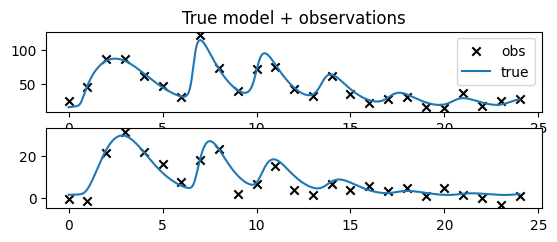

In [22]:
#Generate data
output_ids = [6, 7] # Neuroendocrine = ACTH + Cort
#output_ids = [3, 6, 7] # TNF + ACTH + Cort
# output_ids = [3,4,6,7] #TNF + IL10 + ACTH + Cort

##use generated sets instead
with open('syntheticData\\set1.pkl', 'rb') as f:
    results = pickle.load(f)
y_data = results['y_data']
t_data = results['t_data']

plt.figure()
plt.subplot(4,1,1)
plt.scatter(t_data,y_data[:,0],marker='x',color='k',label='obs')
plt.plot(tfinal,true_sol[:,output_ids[0]],label='true')
plt.title('True model + observations')
plt.legend()
#
plt.subplot(4,1,2)
plt.scatter(t_data,y_data[:,1],marker='x',color='k')
plt.plot(tfinal,true_sol[:,output_ids[1]])

# plt.subplot(4,1,3)
# plt.scatter(t_data,y_data[:,2],marker='x',color='k')
# plt.plot(tfinal,true_sol[:,output_ids[2]])

# plt.subplot(4,1,4)
# plt.scatter(t_data,y_data[:,3],marker='x',color='k')
# plt.plot(tfinal,true_sol[:,output_ids[3]])

plt.show()


In [23]:
# Define which parameters will be updated

##MOST SENSITIVE FOR ACTH + CORT
# param_ids = [33,12,36,32,7,34,31,15,8,9]
param_ids = np.sort([33, 12, 36, 43, 32, 39, 16, 7, 31, 15, 8, 37, 28, 9, 14])
##MOST SENSITIVE FOR ACTH + CORT + TNF-A
#param_ids = [33,12,36,32,7,34,31,15,8,9,16,14,28,26,1]
##MOST SENSITIVE FOR ACTH + CORT + TNF-A + 1L10
# param_ids = [12, 33, 7, 16, 36, 43, 39, 15, 32, 31, 22, 8, 9, 14, 21, 10, 1]
#D1 Selected:
#D2 Selected: [12, 33, 16, 7, 36, 43, 32, 39, 15, 8, 31, 14, 9, 34]
#       ['h6', 'd7', 'd4', 'k3', 'd8', 'T', 'h11', 'beta', 'h7', 'k4', 'k14', 'k6', 'h4', 'k15']
#D3 Selected: [12, 33, 7, 16, 36, 43, 39, 15, 32, 31, 22, 8, 9, 14, 21, 10, 1]
#   ['h6', 'd7', 'k3', 'd4', 'd8', 'T', 'beta', 'h7', 'h11', 'k14', 'd5', 'k4', 'h4', 'k6', 'h9', 'd3', 'k1']

# To make the problem interesting, let's perturb our initial guess of these parameters by 1% [SHOULD WE DO THIS?]
param_in = np.log(np.exp(param_log[param_ids])*np.random.normal(1,0.1,(1,len(param_ids))).flatten())
# print(np.exp(param_log[param_ids]),np.exp(param_in))

# We may also want to constrain the parameters so they do not take on values in "unphysiological" regions
# Define upper bound UB and lower bound LB; remember we are on a log scale!

# MJC - make these bounds based on the parameter values
UB = np.log(np.exp(param_log[param_ids])*10)
LB =  np.log(np.exp(param_log[param_ids])*0.001)
print(UB,param_in,LB)


param_all = param_log.copy()


# Now, we set up a minimization problem
least_sq_sol = least_squares(OLS_res,param_in,args=(y_data,t_data,param_ids,output_ids,param_all,IC),
                             bounds=(LB,UB),verbose=2,xtol=1e-14,diff_step=1e-4)
rel_err = (np.exp(least_sq_sol.x) - np.exp(param_log[param_ids]))/np.exp(param_log[param_ids])
param_err = (np.exp(least_sq_sol.x) - np.exp(param_log[param_ids]))
print("initial guess",np.exp(param_in))
print("optimal solution",np.exp(least_sq_sol.x))
print("true solution",np.exp(param_log[param_ids]))
print("relative error of solution",rel_err)
print("error in parameter space",param_err)
print("objective function value",least_sq_sol.cost) ##This thing




[-17.98500979   1.60943791   8.51719319   0.46310489  12.78026736
   9.64827267  -1.22758267  -1.13943428   7.02108396   6.68461173
  -1.83258146  -1.32425897   8.00636757   9.15904708   9.57498349] [-20.29555165  -0.82034695   6.21992854  -1.73290604  10.41644915
   7.45368393  -3.4477368   -3.33024117   4.69729977   4.09211754
  -4.03536377  -3.58359344   5.72082022   6.93268311   7.2123465 ] [-27.19535017  -7.60090246  -0.69314718  -8.74723548   3.56992698
   0.4379323  -10.43792304 -10.34977466  -2.18925641  -2.52572864
 -11.04292184 -10.53459934  -1.2039728   -0.05129329   0.36464311]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         9.7151e+00                                    2.63e+02    
       1              2         9.2352e+00      4.80e-01       8.11e-01       1.12e+03    
       2              3         7.8240e+00      1.41e+00       1.72e-01       2.07e+03    
       3              5         5.4595e

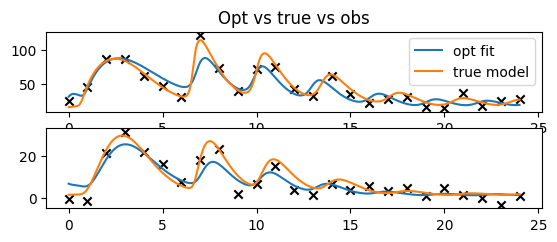

In [24]:
# MJC - plotting to look at solution
param_opt = param_log.copy()
param_opt[param_ids] = least_sq_sol.x

##
opt_model1 = odeint(ITIS, IC, tspace, args = (param_opt,), **ode_options)
IC_2    = opt_model1[-1,:]
IC_2[0] = 2.0
# Resolve model only over 24 hours at subsampled time points. This will be used as our data
opt_model = odeint(ITIS, IC_2, tfinal, args = (param_opt,), **ode_options)



plt.figure()
plt.subplot(4,1,1)
plt.scatter(t_data,y_data[:,0],marker='x',color='k')
plt.plot(tfinal,opt_model[:,output_ids[0]],label='opt fit')
plt.plot(tfinal,true_sol[:,output_ids[0]],label='true model')
plt.title('Opt vs true vs obs')
plt.legend()


plt.subplot(4,1,2)
plt.scatter(t_data,y_data[:,1],marker='x',color='k')
plt.plot(tfinal,opt_model[:,output_ids[1]])
plt.plot(tfinal,true_sol[:,output_ids[1]])


# plt.subplot(4,1,3)
# plt.scatter(t_data,y_data[:,2],marker='x',color='k')
# plt.plot(tfinal,opt_model[:,output_ids[2]])
# plt.plot(tfinal,true_sol[:,output_ids[2]])


# #
# plt.subplot(4,1,4)
# plt.scatter(t_data,y_data[:,3],marker='x',color='k')
# plt.plot(tfinal,opt_model[:,output_ids[3]])
# plt.plot(tfinal,true_sol[:,output_ids[3]])

#plt.savefig("WLS_FIMSelection\\WLS_32.png")
plt.show()

1176281.792934509


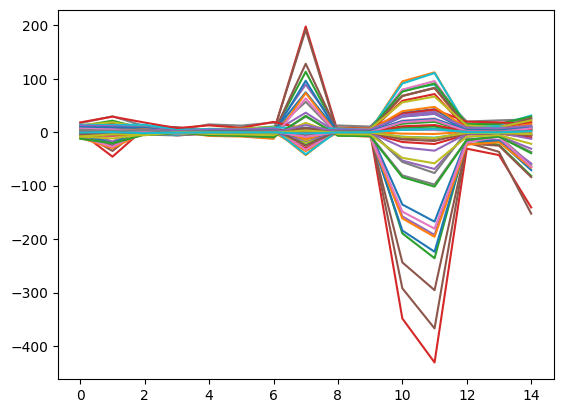

In [25]:
##SENSITIVITY ANALYSIS
h = 1e-6  #amount to perturb parameters
n_param = len(param_ids) #Just the parameters we optimize
n_states = len(output_ids)


Sensitivity_Mat = np.zeros((n_param, len(t_data) * n_states))  ##Initialize shape of sensitivity matrix.
for i in range(n_param):  #calculate the relative sensitivity to each 45 parameters

        param_in = param_opt[param_ids[i]]
        param_delta = param_in + h ##    [HOW EXACTLY SHOULD I BE PERTURBING MY PARAM?]
        ##THIS THING NEXT DO THIS!!!
        Sensitivity_Mat[i, :] = ((1 / h) * (OLS_res(param_delta, y_data, t_data, param_ids[i], output_ids, param_opt, IC)
                                            - OLS_res(param_in, y_data, t_data, param_ids[i], output_ids, param_opt, IC)))

twonorms = np.zeros(n_param)

S_opt = Sensitivity_Mat.copy()
F_opt = S_opt@S_opt.T
print(np.linalg.cond(F_opt))

plt.figure()
plt.plot(S_opt)
plt.show()

for i in range(n_param):
        twonorms[i] = np.power(sum(np.power(Sensitivity_Mat[i, :], 2)), 1 / 2)


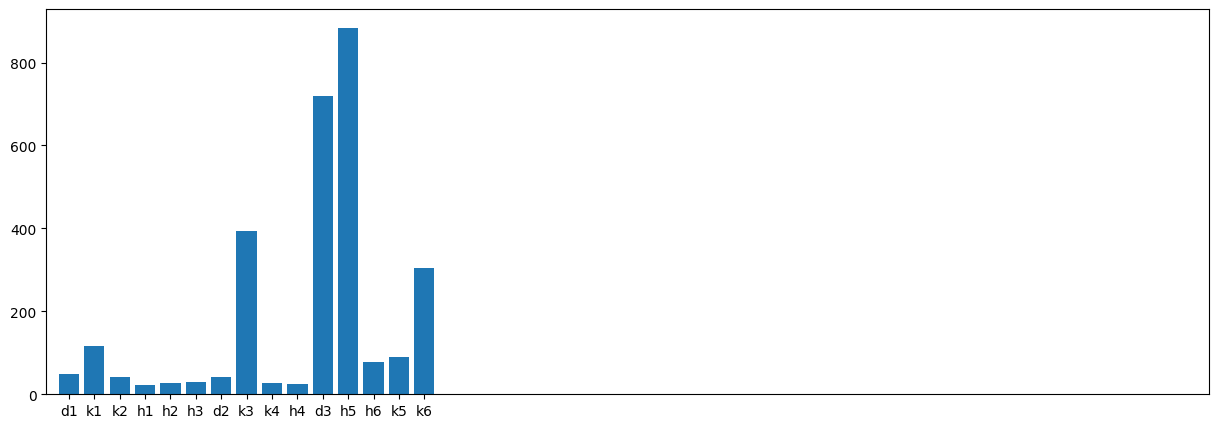

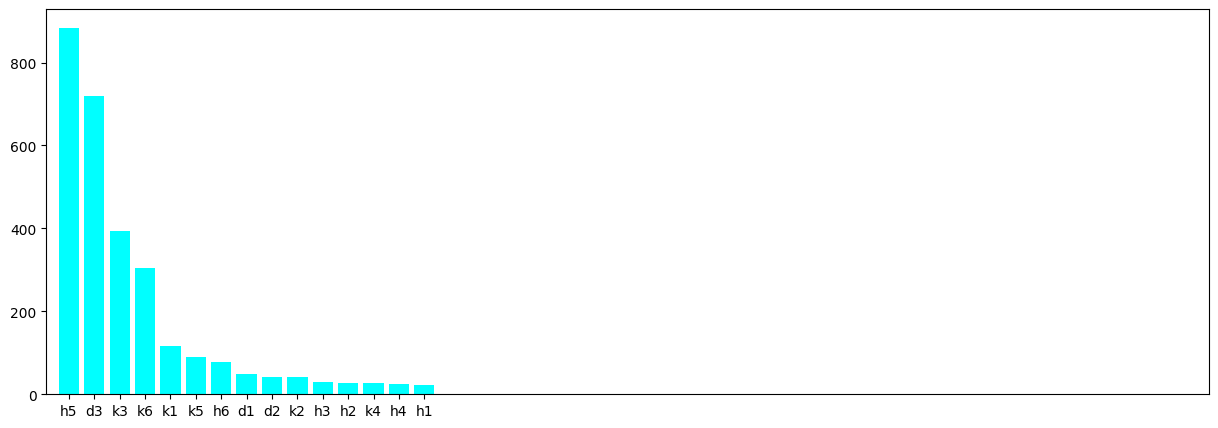

In [26]:
#PLOTTING
paramtitles = ['d1',
               'k1', 'k2', 'h1', 'h2', 'h3', 'd2',
               'k3', 'k4', 'h4', 'd3',
               'h5', 'h6', 'k5', 'k6', 'h7', 'd4',
               'b1', 'k7', 'h8', 'k8', 'h9', 'd5', 'h10',
               'b2', 'k9', 'k10', 'k11', 'd6',
               'k12', 'k13', 'k14', 'h11', 'd7',
               'k15', 'k16', 'd8',
               'alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc']

statetitles = ["Endotoxin", "Phagocytes", "TGF-B", "TNF-a", "IL-10", "CRH", "ACTH", "Cortisol"]
statetitles_Short = ['endo', 'phag', 'TGFB', 'TNF', 'IL10', 'CRH', 'ACTH', 'cort']

fig, ax = plt.subplots(figsize = (15,5))
ax.bar(paramtitles[:len(twonorms)],twonorms)
plt.xlim(-0.9, len(paramtitles) - 1 + 0.9)

##Plot in descending order
data = sorted(zip(paramtitles, twonorms), key=lambda v: v[1], reverse = True)

plt.figure(figsize=(15, 5))
for (i, c) in data:  # unpack and plot each tuple in sorted order
    bars = plt.bar(i, c, align='center', color = 'cyan')
plt.xlim(-0.9, len(paramtitles) - 1 + 0.9)

#plt.savefig("WLS_FIMSelection\\Sens_WLS_32.png")
plt.show()

In [27]:
#Selected for D1 : ['d7', 'h6', 'd8', 'T', 'beta', 'h11', 'k3', 'd4', 'h7', 'k14', 'alpha', 'k4', 'd6', 'h4', 'k6']
#Selected for D2 : ['h6', 'd7', 'd4', 'k3', 'd8', 'T', 'h11', 'beta', 'h7', 'k4', 'k14', 'k6', 'h4', 'k15']
#Selected for D3 : ['h6', 'd7', 'k3', 'd4', 'd8', 'T', 'beta', 'h7', 'h11', 'k14', 'd5', 'k4', 'h4', 'k6', 'h9', 'd3', 'k1']
#H6 IS IMPORTANT BY GLOBAL METRICS, BUT RARELY SHOWS UP AS IMPORTANT IN THIS STEP?

##CURRENT CONCERNS
import pickle

# all_results = {
#     'output_ids': output_ids,
#     'param_ids' : param_ids,
#     'param_in' : param_in,
#     'twonorms' : twonorms,
#     't_data' : t_data,
#     'y_data' : y_data,
#     'opt_model' : opt_model,
#     'true_sol' : true_sol,
#     'param_opt' : param_opt,
#     'optimal_solution' :np.exp(least_sq_sol.x),
#     'objvalue' : least_sq_sol.cost
# }
#
# with open('ResAnalysis32.pkl', 'wb') as f:
#     pickle.dump(all_results, f)
